# Question 3: Adversarial Search - Tic-Tac-Toe with Minimax

## Overview
This notebook describes Question 3 from the assignment, which requires implementing an optimal Tic-Tac-Toe AI using the Minimax algorithm. The AI should play perfectly, ensuring it never loses when playing against any opponent.

## Problem Description
Tic-Tac-Toe is a two-player game on a 3x3 grid. Players alternate placing X and O. The game ends when:
- One player gets three in a row (horizontally, vertically, or diagonally).
- The board is full (tie).

The task is to implement core functions for game logic and use Minimax to find optimal moves.

### Key Requirements
- `player(board)`: Determine whose turn it is.
- `actions(board)`: List valid moves.
- `result(board, action)`: Simulate a move.
- `winner(board)`: Check for a winner.
- `terminal(board)`: Check if game is over.
- `utility(board)`: Evaluate terminal states.
- `minimax(board)`: Compute optimal move.

## Solution Approach
We use the Minimax algorithm to explore the game tree:
- Maximize for X (human), minimize for O (AI).
- Recursively evaluate all possible moves.
- Choose the move leading to the best outcome.

The implementation is in `tictactoe.py`, with a runner in `runner.py` for testing.

### Visual: Game Tree Example

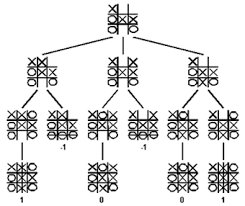

*Diagram showing Minimax tree for Tic-Tac-Toe, with nodes as boards and edges as moves.*

## Code Implementation
Below is the core `tictactoe.py` code (simplified for notebook).

In [ ]:
import copy

X = "X"
O = "O"
EMPTY = None

def initial_state():
    return [[EMPTY, EMPTY, EMPTY],
            [EMPTY, EMPTY, EMPTY],
            [EMPTY, EMPTY, EMPTY]]

def player(board):
    x_count = sum(row.count(X) for row in board)
    o_count = sum(row.count(O) for row in board)
    return O if x_count > o_count else X

def actions(board):
    return {(i, j) for i in range(3) for j in range(3) if board[i][j] == EMPTY}

def result(board, action):
    if action not in actions(board):
        raise Exception("Invalid action")
    new_board = copy.deepcopy(board)
    i, j = action
    new_board[i][j] = player(board)
    return new_board

def winner(board):
    lines = [
        [(0, 0), (0, 1), (0, 2)],
        [(1, 0), (1, 1), (1, 2)],
        [(2, 0), (2, 1), (2, 2)],
        [(0, 0), (1, 0), (2, 0)],
        [(0, 1), (1, 1), (2, 1)],
        [(0, 2), (1, 2), (2, 2)],
        [(0, 0), (1, 1), (2, 2)],
        [(0, 2), (1, 1), (2, 0)],
    ]
    for line in lines:
        values = [board[i][j] for i, j in line]
        if values[0] == values[1] == values[2] != EMPTY:
            return values[0]
    return None

def terminal(board):
    if winner(board) is not None:
        return True
    return all(cell != EMPTY for row in board for cell in row)

def utility(board):
    win = winner(board)
    if win == X:
        return 1
    if win == O:
        return -1
    return 0

def minimax(board):
    if terminal(board):
        return None

    def max_value(state):
        if terminal(state):
            return utility(state)
        v = float("-inf")
        for action in actions(state):
            v = max(v, min_value(result(state, action)))
        return v

    def min_value(state):
        if terminal(state):
            return utility(state)
        v = float("inf")
        for action in actions(state):
            v = min(v, max_value(result(state, action)))
        return v

    current = player(board)
    best_action = None

    if current == X:
        best_score = float("-inf")
        for action in actions(board):
            score = min_value(result(board, action))
            if score > best_score:
                best_score = score
                best_action = action
    else:
        best_score = float("inf")
        for action in actions(board):
            score = max_value(result(board, action))
            if score < best_score:
                best_score = score
                best_action = action

    return best_action

## Demonstration
Let's test the functions and simulate a game.

In [ ]:
# Test initial state
board = initial_state()
print("Initial board:")
for i, row in enumerate(board):
    print(" " + " | ".join(cell if cell else " " for cell in row))
    if i < 2:
        print("---+---+---")
print()

print(f"Current player: {player(board)}")
print(f"Actions: {actions(board)}")
print(f"Minimax move: {minimax(board)}")

### Screenshot: Terminal Game Output

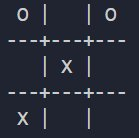

*Board state during gameplay — X and O placed on the 3x3 grid.*

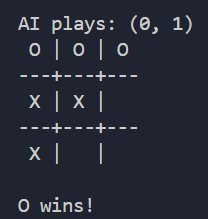

*Screenshot of running `runner.py` in terminal, showing board display and AI move — O wins!*

## Conclusion
The Minimax implementation ensures optimal play. The AI evaluates all possibilities, making it unbeatable. For full gameplay, run `runner.py`.

### Visual: Win Scenarios

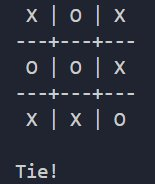

*Example of a tied game — all cells filled with no winner.*